# Ansatz Comparison: H2

This notebook compares several VQE ansätze on the hydrogen molecule **H2**.

Goals:

- run the same optimization workflow with different ansätze
- compare convergence behaviour
- compare final energies against the exact ground-state reference

This is a simple way to see how ansatz choice changes variational performance.

In [ ]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt

from vqe.core import run_vqe
from common.hamiltonian import get_exact_spectrum

## Setup

We keep the molecule, optimizer, step count, and random seed fixed.

Only the ansatz changes.

In [6]:
molecule = "H2"
optimizer_name = "Adam"
steps = 50
stepsize = 0.2
seed = 0

ansatz_names = [
    "Minimal",
    "RY-CZ",
    "UCCSD",
]

## Exact ground-state reference

For a small system like `H2`, we can compare each variational result against
the exact ground-state energy.

In [7]:
exact_spectrum = np.asarray(get_exact_spectrum(molecule), dtype=float)
exact_spectrum = np.sort(exact_spectrum)
exact_ground_energy = float(exact_spectrum[0])

exact_ground_energy

-1.1372701748841751

## Run VQE for each ansatz

In [ ]:
results = {}

for ansatz_name in ansatz_names:
    print(f"Running {ansatz_name} ...")
    res = run_vqe(
        molecule=molecule,
        ansatz_name=ansatz_name,
        optimizer_name=optimizer_name,
        steps=steps,
        stepsize=stepsize,
        seed=seed,
        noisy=False,
        force=True,
        plot=False,
    )
    results[ansatz_name] = res

Running Minimal ...
Step 01/50: E = 0.713612 Ha
Step 02/50: E = 0.692164 Ha
Step 03/50: E = 0.649641 Ha
Step 04/50: E = 0.579497 Ha
Step 05/50: E = 0.482266 Ha
Step 06/50: E = 0.359728 Ha
Step 07/50: E = 0.214881 Ha
Step 08/50: E = 0.051977 Ha
Step 09/50: E = -0.123483 Ha
Step 10/50: E = -0.304849 Ha
Step 11/50: E = -0.484535 Ha
Step 12/50: E = -0.654375 Ha
Step 13/50: E = -0.806176 Ha
Step 14/50: E = -0.932467 Ha
Step 15/50: E = -1.027441 Ha
Step 16/50: E = -1.088003 Ha
Step 17/50: E = -1.114649 Ha
Step 18/50: E = -1.111816 Ha
Step 19/50: E = -1.087299 Ha
Step 20/50: E = -1.050700 Ha
Step 21/50: E = -1.011428 Ha
Step 22/50: E = -0.977043 Ha
Step 23/50: E = -0.952462 Ha
Step 24/50: E = -0.939988 Ha
Step 25/50: E = -0.939805 Ha
Step 26/50: E = -0.950573 Ha
Step 27/50: E = -0.969970 Ha
Step 28/50: E = -0.995118 Ha
Step 29/50: E = -1.022935 Ha
Step 30/50: E = -1.050435 Ha
Step 31/50: E = -1.075008 Ha
Step 32/50: E = -1.094660 Ha
Step 33/50: E = -1.108190 Ha
Step 34/50: E = -1.115286 Ha
St

## Final energies

In [9]:
summary_rows = []

for ansatz_name, res in results.items():
    final_energy = float(res["energy"])
    abs_error = abs(final_energy - exact_ground_energy)
    n_steps = len(res["energies"])

    summary_rows.append((ansatz_name, final_energy, abs_error, n_steps))

summary_rows

[('Minimal', -1.1165541367321838, 0.0207160381519913, 51),
 ('RY-CZ', -1.110727768500239, 0.026542406383936124, 51),
 ('UCCSD', -1.1371763798704708, 9.379501370432308e-05, 51)]

In [10]:
for ansatz_name, final_energy, abs_error, n_steps in summary_rows:
    print(
        f"{ansatz_name:>24} | "
        f"final = {final_energy:.10f} | "
        f"abs error = {abs_error:.6e} | "
        f"steps = {n_steps}"
    )

                 Minimal | final = -1.1165541367 | abs error = 2.071604e-02 | steps = 51
                   RY-CZ | final = -1.1107277685 | abs error = 2.654241e-02 | steps = 51
                   UCCSD | final = -1.1371763799 | abs error = 9.379501e-05 | steps = 51


## Convergence curves

Plot the energy trajectory for each ansatz on the same axes.

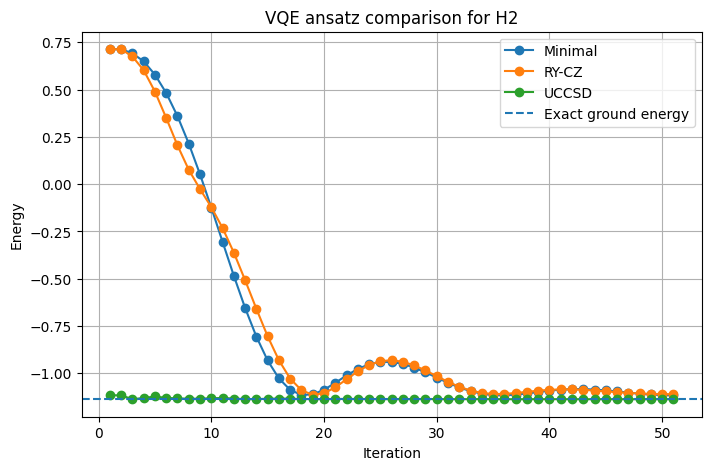

In [11]:
plt.figure(figsize=(8, 5))

for ansatz_name, res in results.items():
    energies = np.asarray(res["energies"], dtype=float)
    plt.plot(
        np.arange(1, len(energies) + 1),
        energies,
        marker="o",
        label=ansatz_name,
    )

plt.axhline(exact_ground_energy, linestyle="--", label="Exact ground energy")
plt.xlabel("Iteration")
plt.ylabel("Energy")
plt.title("VQE ansatz comparison for H2")
plt.grid(True)
plt.legend()
plt.show()

## Final-energy comparison

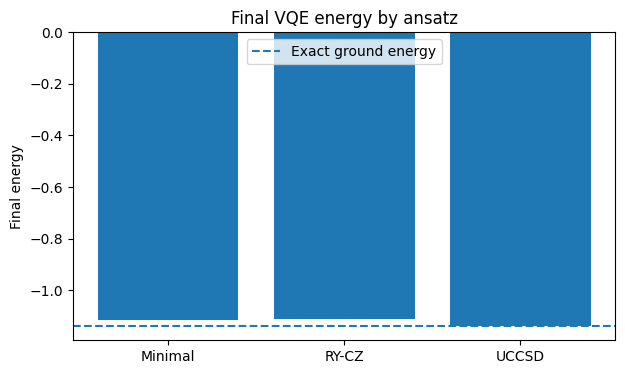

In [12]:
final_energies = [float(results[name]["energy"]) for name in ansatz_names]

plt.figure(figsize=(7, 4))
plt.bar(ansatz_names, final_energies)
plt.axhline(exact_ground_energy, linestyle="--", label="Exact ground energy")
plt.ylabel("Final energy")
plt.title("Final VQE energy by ansatz")
plt.legend()
plt.show()

## Interpretation

Typical things to look for:

- which ansatz reaches the lowest final energy
- which ansatz converges fastest
- which ansatz appears most stable during optimization

For small chemistry problems, **UCCSD** is often a strong baseline because it
incorporates chemically motivated excitation structure.

Simpler ansätze can still be useful:

- **Minimal** for pedagogy and debugging
- **RY-CZ** for lightweight hardware-oriented baselines

## What this notebook showed

We:

- ran VQE on the same molecule with multiple ansätze
- compared convergence curves
- compared final energies to the exact ground-state reference

This isolates the effect of ansatz choice while keeping the rest of the
workflow fixed.

## Next steps

Good follow-ups are:

- compare optimizers with a fixed ansatz
- compare mappings on the same molecule
- repeat the study on `H3+` or another small system